In [1]:
import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import TFAutoModel
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import cv2
import imutils
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

2025-06-10 08:13:39.174321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749543219.363076      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749543219.415683      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# laod Kagle dateset
train_dir = "/kaggle/input/research-dataset/Kaggle/Training"

# Read all images and their labels
all_images = []
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        all_images.append({
            "image_path": os.path.join(class_dir, img_file),
            "label": class_name
        })

kaggle_df = pd.DataFrame(all_images)

# Encode labels
label_to_idx = {label: idx for idx, label in enumerate(sorted(kaggle_df["label"].unique()))}
kaggle_df["label"] = kaggle_df["label"].map(label_to_idx)

# Stratified split (80% train, 20% val)
train_df, val_df = train_test_split(kaggle_df, test_size=0.2, stratify=kaggle_df["label"], random_state=42)

print(f"Kaggle split: Train = {len(train_df)}, Val = {len(val_df)}")

Kaggle split: Train = 4569, Val = 1143


In [3]:
# Load OASIS 
oasis_root = "/kaggle/input/research-dataset/OASIS"

labels_df = pd.read_csv(os.path.join(oasis_root, "labels.csv"))

# Check for dementia_multi column
if 'dementia_multi' not in labels_df.columns:
    raise ValueError("Column 'dementia_multi' not found in the CSV file. Available columns: " + str(labels_df.columns.tolist()))

# Create image paths
labels_df["image_path"] = labels_df["ID"].apply(
    lambda x: os.path.join("/kaggle/input/research-dataset/OASIS", f"{x}_slice0.png")
)
 
# Rename the label column
labels_df = labels_df.rename(columns={"dementia_multi": "label"})

# Handle label conversion
if labels_df["label"].dtype == object:
    label_mapping = {
        "Control": 0,
        "MildCognitiveImpairment": 1,
        "Demented": 2
    }
    labels_df["label"] = labels_df["label"].map(label_mapping)
    
    # Verify mapping
    if labels_df["label"].isna().any():
        unmapped = labels_df[labels_df["label"].isna()]["label"].unique()
        raise ValueError(f"Some labels were not mapped: {unmapped}")


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 8

In [ ]:
def crop_img(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    return img[y:y+h, x:x+w]

def process_folder(input_root, output_root):
    for category in os.listdir(input_root):
        category_path = os.path.join(input_root, category)
        if not os.path.isdir(category_path):
            continue

        save_dir = os.path.join(output_root, category)
        os.makedirs(save_dir, exist_ok=True)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            cropped = crop_img(img)
            if cropped is None:
                continue

            resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            save_path = os.path.join(save_dir, img_name)
            cv2.imwrite(save_path, resized)

if __name__ == "__main__":
    process_folder("/kaggle/input/research-dataset/Kaggle/Training", "cleaned/Training")
    process_folder("/kaggle/input/research-dataset/Kaggle/Testing", "cleaned/Testing")

In [6]:
# === DATA LOADERS ===
train_dir = "cleaned/Training"
val_dir = "cleaned/Testing"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_dir,
                                           target_size=(IMG_SIZE, IMG_SIZE),
                                           batch_size=BATCH_SIZE,
                                           class_mode='categorical')

val_data = val_gen.flow_from_directory(val_dir,
                                       target_size=(IMG_SIZE, IMG_SIZE),
                                       batch_size=BATCH_SIZE,
                                       class_mode='categorical',
                                       shuffle=False)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [7]:
def get_model_vit(input_shape=(224, 224, 3), num_classes=4, trainable_layers=0):
    inputs = tf.keras.Input(shape=input_shape)
    feature_extractor = TFAutoModel.from_pretrained("google/vit-base-patch16-224-in21k")
    
    # Freezing strategy
    for layer in feature_extractor.layers:
        layer.trainable = False
    if trainable_layers > 0:
        for layer in feature_extractor.layers[-trainable_layers:]:
            layer.trainable = True

    # Forward pass
    def feature_forward(x):
        x = tf.transpose(x, perm=[0, 3, 1, 2])  # Fix input shape for ViT
        outputs = feature_extractor(pixel_values=x, training=False)
        return outputs.last_hidden_state[:, 0, :]  # CLS token
    
    x = tf.keras.layers.Lambda(
        feature_forward,
        output_shape=(768,)  # Hidden size of ViT-Base
    )(inputs)

    # Classifier Top
    x = tf.keras.layers.Dense(256, activation='swish')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [8]:
model = get_model_vit(input_shape=(224,224,3), num_classes=4, trainable_layers=4)
model.summary()

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

I0000 00:00:1749543311.259186      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749543311.259905      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         196,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 197,892 (773.02 KB)

 Trainable params: 197,892 (773.02 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4)


model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time() 
history = model.fit(train_data,
                    validation_data=val_data,
                    epochs=50)
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Training completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1749543329.505543      99 service.cc:148] XLA service 0x7a51b40034d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749543329.506518      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749543329.506538      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749543331.641531      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/714 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.4375 - loss: 1.4281   

I0000 00:00:1749543334.512236      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


714/714 ━━━━━━━━━━━━━━━━━━━━ 106s 119ms/step - accuracy: 0.7359 - loss: 0.6776 - val_accuracy: 0.8589 - val_loss: 0.4099
Epoch 2/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.8804 - loss: 0.3201 - val_accuracy: 0.8871 - val_loss: 0.2940
Epoch 3/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.9024 - loss: 0.2652 - val_accuracy: 0.9031 - val_loss: 0.2442
Epoch 4/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 86s 120ms/step - accuracy: 0.9150 - loss: 0.2282 - val_accuracy: 0.8955 - val_loss: 0.2659
Epoch 5/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.9195 - loss: 0.2027 - val_accuracy: 0.9001 - val_loss: 0.2459
Epoch 6/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 86s 120ms/step - accuracy: 0.9204 - loss: 0.1990 - val_accuracy: 0.9161 - val_loss: 0.2119
Epoch 7/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - accuracy: 0.9407 - loss: 0.1553 - val_accuracy: 0.8986 - val_loss: 0.2494
Epoch 8/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - accuracy: 0.9403 - loss: 0.1687 - va

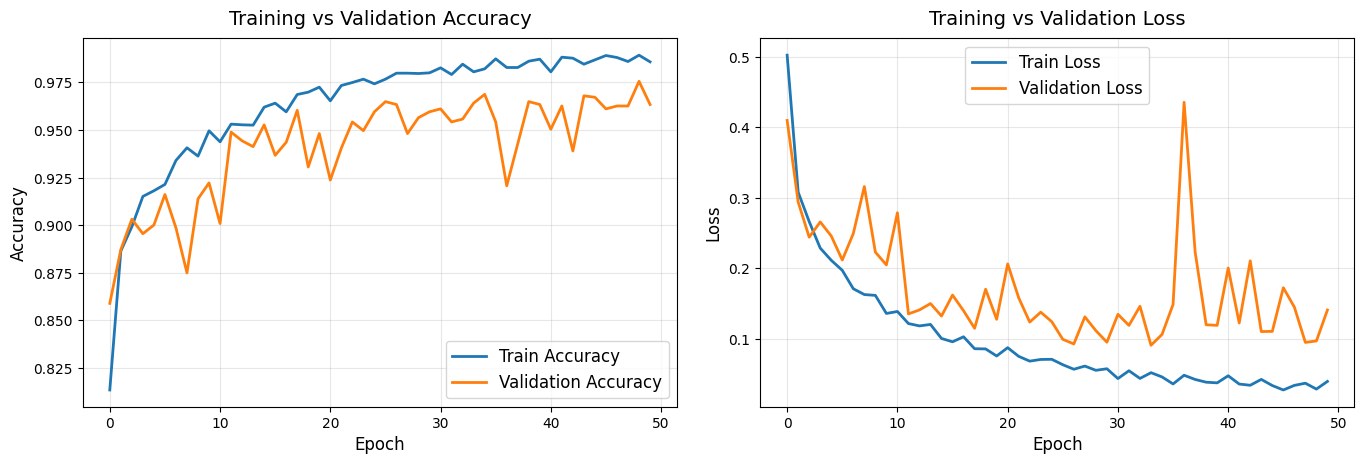

In [10]:
# Create figure with two subplots
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14, pad=10)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14, pad=10)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout(pad=2.0)
plt.show()

164/164 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step
=== Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       300
           1       0.92      0.96      0.94       306
           2       1.00      1.00      1.00       405
           3       1.00      0.91      0.95       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311

=== Confusion Matrix ===


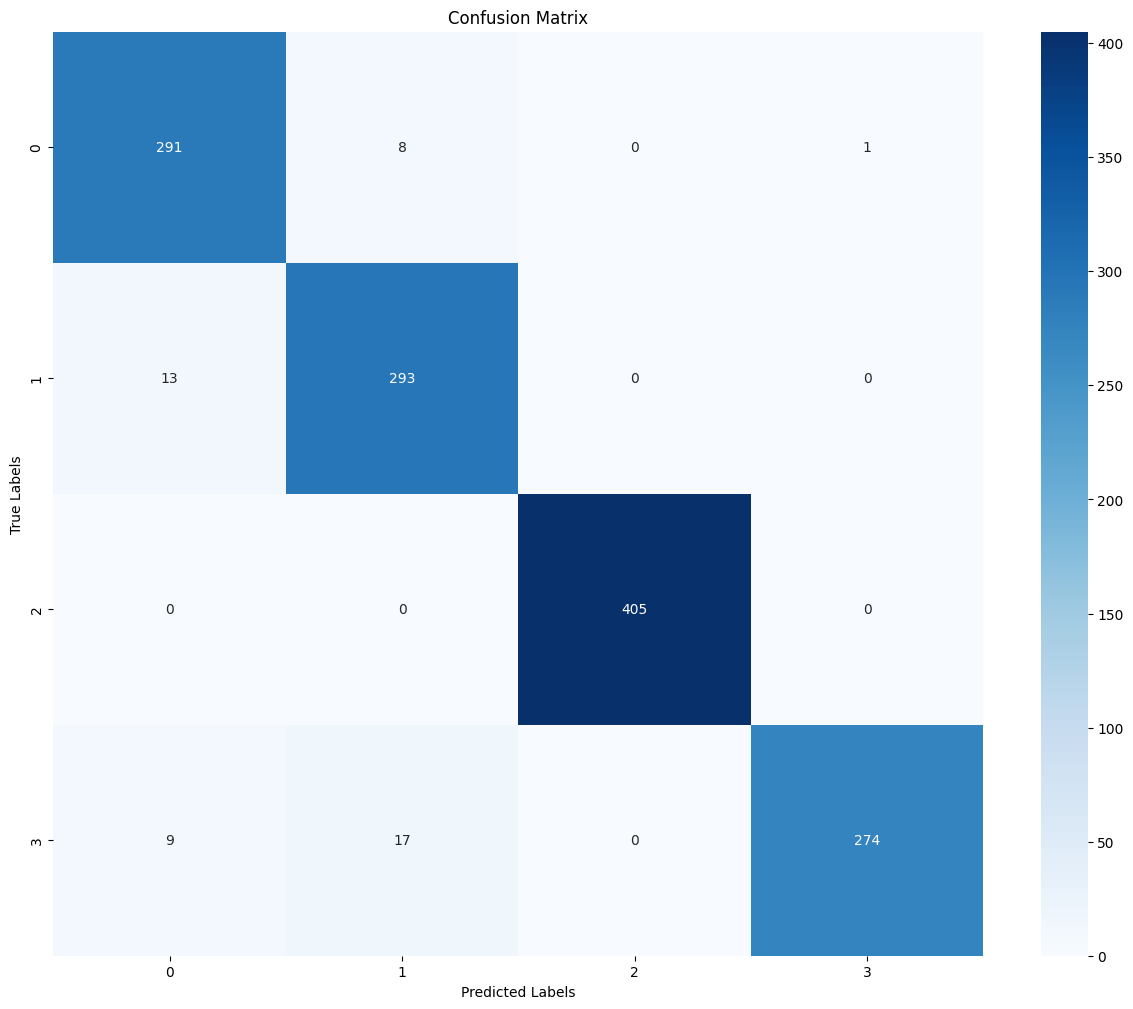

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

# Classification report
print("=== Classification Report ===")
print(classification_report(y_true, y_pred))

# Confusion matrix
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # annot=True and fmt='d' for integer formatting
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [12]:
# === 1. LOAD LABELS ===
labels_df = pd.read_csv("/kaggle/input/research-dataset/OASIS/labels.csv")

# First check if 'dimentia_multi' column exists
if 'dementia_multi' not in labels_df.columns:
    raise ValueError("Column 'dimentia_multi' not found in the CSV file. Available columns: " + str(labels_df.columns.tolist()))

# Create image paths
labels_df["image_path"] = labels_df["ID"].apply(
    lambda x: os.path.join("/kaggle/input/research-dataset/OASIS", f"{x}_slice0.png")
)

# Rename the label column
labels_df = labels_df.rename(columns={"dementia_multi": "label"})

# Now handle label conversion if needed
if labels_df["label"].dtype == object:
    # Adjust this mapping to match your actual class names
    label_mapping = {
        "Control": 0,
        "MildCognitiveImpairment": 1,  # Note: Fix typo if needed
        "Demented": 2
    }
    labels_df["label"] = labels_df["label"].map(label_mapping)
    
    # Verify all labels were mapped
    if labels_df["label"].isna().any():
        unmapped = labels_df[labels_df["label"].isna()]["label"].unique()
        raise ValueError(f"Some labels were not mapped: {unmapped}")

In [13]:
def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)  # ← switch from decode_image
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def make_dataset(df, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["label"].values))
    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        ds = ds.map(lambda x, y: (augment_image(x), y), 
                   num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.1)
    # Random zoom and crop
    image = tf.image.central_crop(image, central_fraction=0.8)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image


In [14]:
train_df, val_df = train_test_split(labels_df, test_size=0.2, stratify=labels_df["label"], random_state=42)

In [15]:
# Training dataset with augmentation
train_ds_oasis = make_dataset(train_df, augment=True)

# Validation dataset without augmentation
val_ds_oasis = make_dataset(val_df, augment=False)

In [16]:
NUM_CLASSES_OASIS = 3

print(f"\nOriginal model input shape: {model.input_shape}, output shape: {model.output_shape}")

# Get feature extractor output
feature_extractor_output = model.layers[1].output

# Add new classification head
x_oasis = tf.keras.layers.Dense(128, activation='swish', name='oasis_dense_1')(feature_extractor_output)
x_oasis = tf.keras.layers.Dropout(0.3, name='oasis_dropout_1')(x_oasis)
oasis_outputs = tf.keras.layers.Dense(NUM_CLASSES_OASIS, activation='softmax', name='oasis_classifier_output')(x_oasis)

# Create new model
oasis_model = tf.keras.Model(inputs=model.inputs, outputs=oasis_outputs)

# Freeze base layers
for layer in oasis_model.layers:
    if layer.name.startswith('oasis_'):
        layer.trainable = True
    else:
        layer.trainable = False

# Compile model
oasis_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # Changed to sparse for integer labels
    metrics=['accuracy']
)

# Training parameters
OASIS_EPOCHS = 30
start_time = time.time()

history = oasis_model.fit(
    train_ds_oasis,
    validation_data=val_ds_oasis,
    epochs=OASIS_EPOCHS,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time/60:.2f} minutes")


Original model input shape: (None, 224, 224, 3), output shape: (None, 4)
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 346ms/step - accuracy: 0.6935 - loss: 0.8781 - val_accuracy: 0.7727 - val_loss: 0.6663
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.7852 - loss: 0.6361 - val_accuracy: 0.7727 - val_loss: 0.6545
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.7899 - loss: 0.6028 - val_accuracy: 0.7614 - val_loss: 0.6553
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7704 - loss: 0.6366 - val_accuracy: 0.7614 - val_loss: 0.6597
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.8064 - loss: 0.5736 - val_accuracy: 0.7841 - val_loss: 0.6799
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.8020 - loss: 0.5812 - val_accuracy: 0.7727 - val_loss: 0.6706
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.7662 - loss: 0.6158 - val_accuracy: 0.7841 - val_loss: 0.6739
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.7964 - loss: 0.5897 - val_accuracy: 0.7955 - val


=== Making Predictions ===


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(8, 224, 224, 3))
  warnings.warn(msg)



======================================== Classification Report ========================================
              precision    recall  f1-score   support

     Control     0.8485    0.8235    0.8358        68
         MCI     0.3333    0.5000    0.4000        14
    Demented     1.0000    0.1667    0.2857         6

    accuracy                         0.7273        88
   macro avg     0.7273    0.4967    0.5072        88
weighted avg     0.7769    0.7273    0.7290        88




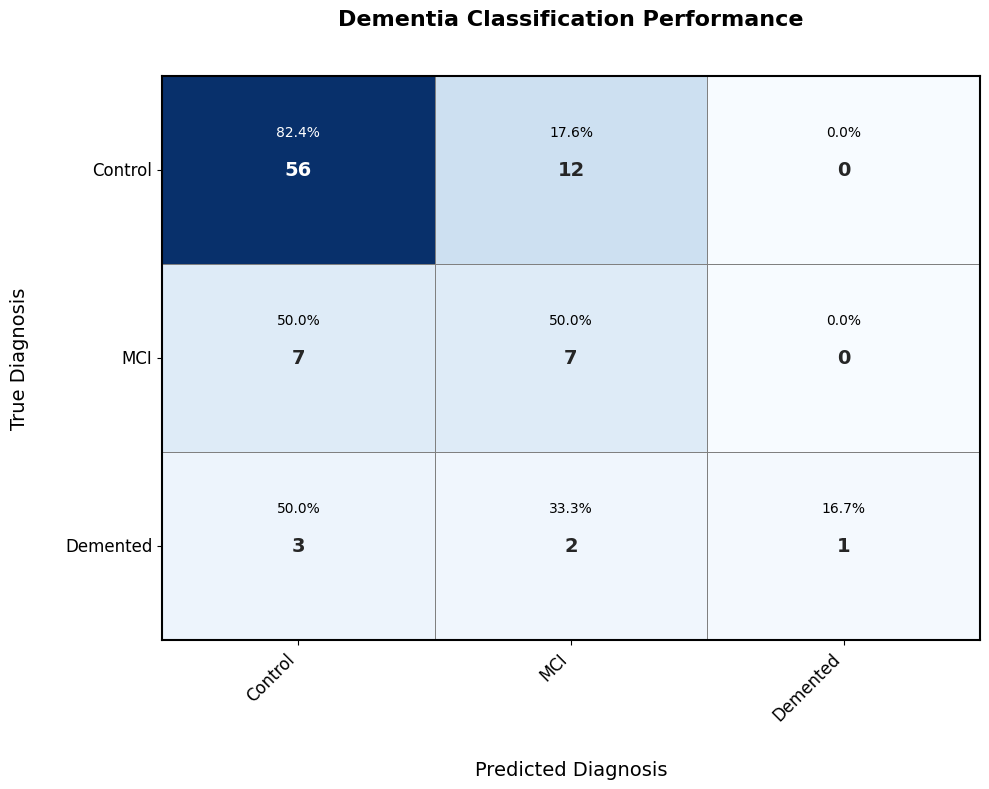


======================================== Clinical Metrics ========================================
Overall Accuracy: 0.7273
AD Detection Sensitivity (Recall): 0.1667
AD Detection Specificity: 1.0000
MCI Detection F1-Score: 0.4000


In [18]:
# === EVALUATION CELL ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Define class names matching your label mapping
class_names = ['Control', 'MCI', 'Demented']  # MCI = Mild Cognitive Impairment

# Get predictions and true labels
print("\n=== Making Predictions ===")
y_pred = []
y_true = []

for images, labels in val_ds_oasis:
    preds = oasis_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# === Classification Report ===
print("\n" + "="*40 + " Classification Report " + "="*40)
print(classification_report(y_true, y_pred, 
                          target_names=class_names,
                          digits=4))
print("="*100 + "\n")

# === Confusion Matrix ===
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)

# Create heatmap with custom annotations
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                cbar=False,
                annot_kws={"size": 14, "weight": "bold"},
                linewidths=0.5, linecolor='grey')

# Add percentages to confusion matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):
        total = cm[i].sum()
        percentage = f"{cm[i,j]/total:.1%}" if total > 0 else "0%"
        ax.text(j+0.5, i+0.3, percentage, 
               ha="center", va="center", 
               color="white" if cm[i,j] > cm.max()/2 else "black",
               fontsize=10)

# Formatting
plt.title("Dementia Classification Performance\n", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("\nPredicted Diagnosis", fontsize=14, labelpad=10)
plt.ylabel("True Diagnosis\n", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Add border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    
plt.tight_layout()
plt.show()

# === Clinical Performance Metrics ===
print("\n" + "="*40 + " Clinical Metrics " + "="*40)
print(f"Overall Accuracy: {np.mean(y_true == y_pred):.4f}")
print(f"AD Detection Sensitivity (Recall): {cm[2,2]/cm[2,:].sum():.4f}")
print(f"AD Detection Specificity: {(cm[0,0]+cm[0,1]+cm[1,0]+cm[1,1])/(cm[0,:].sum()+cm[1,:].sum()):.4f}")
print(f"MCI Detection F1-Score: {2*(cm[1,1]/(cm[1,:].sum()+cm[:,1].sum())):.4f}")
print("="*100)